# Medidas de variabilidad

**Almacenes y Minería de Datos · Práctica 4**

Este notebook calcula las medidas de variabilidad del conjunto ENDIREH 2021 ya preprocesado y explica cómo leerlas. Los cálculos provienen de `src/visualization/eda.py` y la figura de `src/visualization/graficas.py`; aquí solo se presentan los resultados y su interpretación.

## 1. Qué son las medidas de variabilidad

Las medidas de variabilidad indican qué tan dispersos están los datos alrededor de su centro. Completan a las de localización, porque dos grupos pueden tener el mismo centro y repartirse de forma muy distinta.

| Medida | Qué indica | Fórmula |
|---|---|---|
| Rango | La distancia entre el valor más alto y el más bajo | $x_{\max} - x_{\min}$ |
| Varianza | El promedio de las distancias al cuadrado respecto a la media | $s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$ |
| Desviación estándar | La raíz de la varianza, en las mismas unidades que la variable | $s = \sqrt{s^2}$ |
| Coeficiente de variación (CV) | La desviación estándar como porcentaje de la media | $CV = \frac{s}{\bar{x}} \times 100\,\%$ |
| Rango intercuartílico (IQR) | El ancho del intervalo que contiene la mitad central de los datos | $IQR = Q_3 - Q_1$ |

El rango, la varianza, la desviación estándar y el CV son sensibles a los valores extremos: unos cuantos valores muy altos bastan para elevarlos. El IQR solo considera la mitad central de los datos y por eso resiste a esos valores.

El CV es la medida adecuada para comparar grupos. Al expresar la dispersión como porcentaje de la media, permite comparar grupos cuyas medias son distintas, algo que la desviación estándar por sí sola no permite.

### Comparación entre grupos y ponderación

Cada medida se calcula para el total y para dos grupos: las mujeres que reportaron violencia de pareja y las que no.

Estas medidas se calculan sin ponderar. Describen la dispersión dentro de cada grupo de encuestadas. Estimar la dispersión en la población requeriría una varianza que tome en cuenta el diseño muestral de la encuesta, lo que queda fuera del alcance de la práctica.

## 2. Datos

Se parte del archivo que produce `src/cleaning/limpieza.py`. Como en el notebook de medidas de localización, la variable que se interpreta es `ingreso_pareja`, que solo tiene valor cuando la pareja de la encuestada trabaja.

In [1]:
import sys
from pathlib import Path

import polars as pl
from IPython.display import Image, display

# La raíz del proyecto entra al path para importar config/ y src/.
RAIZ = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
sys.path.append(str(RAIZ))

from config.rutas import RUTA_ENDIREH_LIMPIO, RUTA_FIGURAS
from src.visualization.eda import seccion_variabilidad
from src.visualization.graficas import figura_07_boxplot_ingreso

df = pl.read_parquet(RUTA_ENDIREH_LIMPIO)

print(f"Registros: {df.height:,}")
print(f"Registros con ingreso de la pareja: {df['ingreso_pareja'].is_not_null().sum():,}")

Registros: 105,752
Registros con ingreso de la pareja: 48,858


## 3. Resultados

### 3.1 Ingreso de la pareja

In [2]:
seccion_variabilidad(df, ["ingreso_pareja"])


 MEDIDAS DE VARIABILIDAD

Comparación entre el grupo que reportó violencia de pareja y el que no.
Las medidas van sin ponderar: el CV compara dispersión relativa dentro
de cada grupo, no estima un total poblacional.

--- ingreso_pareja
    Medida                   Total   Con violencia   Sin violencia
    ------------------------------------------------------------
    n                       48,858          10,072          38,786
    Media                 3,731.39        3,212.59        3,866.12
    Rango               800,000.00       80,000.00      800,000.00
    Varianza         50,039,813.41   22,927,409.72   56,993,123.76
    Desv. estándar        7,073.88        4,788.26        7,549.38
    CV (%)                  189.58          149.05          195.27
    IQR                   3,500.00        2,600.00        3,900.00

    Razón de CV (con/sin): 0.76


**Interpretación.** La dispersión es alta en los dos grupos. La desviación estándar supera a la media, con un CV de 149.05 % en el grupo que reportó violencia y de 195.27 % en el que no. Un CV por encima de 100 % es coherente con la distribución sesgada a la derecha que mostraron las medidas de localización.

El grupo que reportó violencia es menos disperso en todas las medidas. Su rango es de 80,000 pesos frente a 800,000, su desviación estándar de 4,788.26 pesos frente a 7,549.38 y su IQR de 2,600 pesos frente a 3,900. La razón entre los dos CV es de 0.76.

Una parte de esa diferencia se debe a los valores extremos. En el grupo que no reportó violencia hay ingresos de hasta 800,000 pesos, que elevan su rango, su varianza y su desviación estándar; en el otro grupo el máximo es de 80,000. El IQR no depende de esos valores y también es menor en el grupo que reportó violencia. La diferencia, entonces, no se limita a unos cuantos casos extremos: la mitad central de sus ingresos ocupa un intervalo más estrecho.

Esta comparación describe lo que las encuestadas reportaron. No permite afirmar que un ingreso más bajo o menos disperso cause violencia, ni lo contrario, porque la encuesta registra ambas cosas en un mismo momento. La diferencia también puede reflejar una disposición distinta a reportar.

### 3.2 Diagrama de caja

El diagrama de caja resume la misma comparación. La caja va del primer al tercer cuartil, la línea interior marca la mediana y los bigotes llegan al último valor que queda dentro de 1.5 veces el IQR. La figura usa escala lineal y no dibuja los valores atípicos, que se cuantifican en el pie.

[graficas] reports/figuras/07_boxplot_ingreso_por_violencia.png


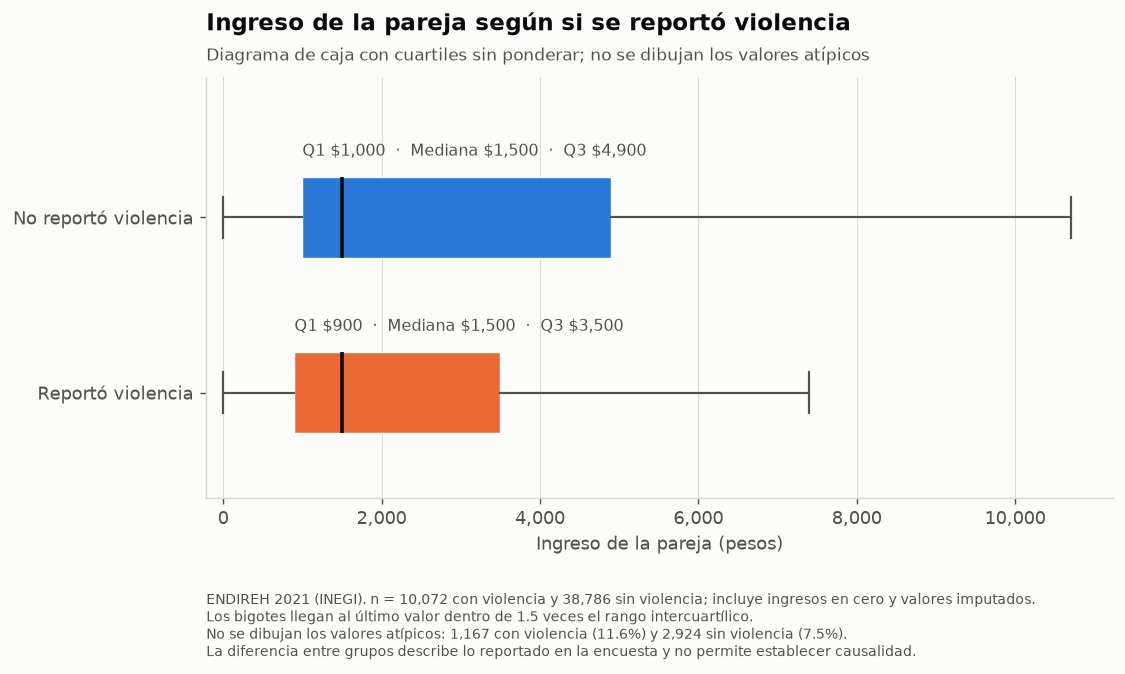

In [3]:
figura_07_boxplot_ingreso(df)
display(Image(filename=str(RUTA_FIGURAS / "07_boxplot_ingreso_por_violencia.png")))

**Interpretación.** Los dos grupos comparten la mediana, de 1,500 pesos, y tienen casi el mismo primer cuartil, de 900 y 1,000 pesos. La diferencia aparece en la parte alta: el tercer cuartil es de 3,500 pesos en el grupo que reportó violencia y de 4,900 en el que no, y el bigote superior llega a 7,400 y a 10,700 pesos. Los grupos se parecen en los ingresos bajos y medios y se separan en los altos, que son menos frecuentes entre las mujeres que reportaron violencia.

Los valores atípicos que no se dibujan son el 11.6 % en el grupo que reportó violencia y el 7.5 % en el otro. Dejarlos fuera de la figura no los quita del análisis: están incluidos en todas las medidas de la tabla anterior y explican la distancia entre el rango y el IQR.

### 3.3 Variables de significado no confirmado

Las medidas de `edad_primer_union` y `num_hijos` se calculan con el mismo procedimiento. Igual que en el notebook de medidas de localización, se muestran sin interpretar, porque el archivo consolidado no permite confirmar qué mide cada una.

In [4]:
seccion_variabilidad(df, ["edad_primer_union", "num_hijos"])


 MEDIDAS DE VARIABILIDAD

Comparación entre el grupo que reportó violencia de pareja y el que no.
Las medidas van sin ponderar: el CV compara dispersión relativa dentro
de cada grupo, no estima un total poblacional.

--- edad_primer_union
    Medida                   Total   Con violencia   Sin violencia
    ------------------------------------------------------------
    n                       23,662           8,467          15,195
    Media                    10.03           10.03           10.03
    Rango                    76.00           72.00           76.00
    Varianza                114.90          110.52          117.35
    Desv. estándar           10.72           10.51           10.83
    CV (%)                  106.86          104.86          107.96
    IQR                      13.00           13.00           13.00

    Razón de CV (con/sin): 0.97

--- num_hijos
    Medida                   Total   Con violencia   Sin violencia
    ----------------------------------------

Lo único que se señala es descriptivo: en ambas variables el CV de los dos grupos es casi igual, con razones de 0.97 y 1.03.

## 4. Valor para la tabla del reporte

En la fila de variabilidad de la tabla de resultados se usa `ingreso_pareja`. El CV es de 149.05 % en el grupo que reportó violencia y de 195.27 % en el que no, y el IQR de 2,600 y 3,900 pesos. La lectura es que el ingreso de la pareja está muy disperso en ambos grupos y que el grupo que reportó violencia es más homogéneo, porque en él son menos frecuentes los ingresos altos. Se trata de una asociación observada en lo reportado y no de una relación causal.